# Q-Learning with Gymnasium Blackjack-v1
## Problem formulation, exact optimal Q-values, training, convergence, policy maps, and trained-agent rendering

This notebook uses the **built-in Gymnasium `Blackjack-v1` environment**.

The agent plays a simplified game of Blackjack against a dealer. At each decision, it must choose whether to **hit** and receive another card or **stick** and end its turn.

This is a useful Q-Learning portfolio example because:

- the state is discrete and interpretable;
- the action space contains only two actions;
- the learned policy can be visualized clearly;
- the optimal action-value function can be computed independently and compared with the learned Q-table.

The notebook includes:

- problem description;
- state, action, reward, and terminal condition;
- environment rendering;
- Q-Learning from scratch;
- first 60 Q-value updates;
- an independently computed reference $Q^*$;
- convergence graph;
- learned Q-table;
- policy heatmaps;
- evaluation against many games;
- a rendered episode played by the trained agent.

In [1]:
%pip install -q "gymnasium[toy-text]" imageio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 34.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from functools import lru_cache
import imageio.v2 as imageio
from IPython.display import Image as IPyImage, display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", 20)

## 1. Problem Description

The agent is the player in Blackjack.

The goal is to obtain a hand value closer to 21 than the dealer without exceeding 21.

The player can repeatedly request another card or stop taking cards.

### State

Gymnasium represents each state as

$$
S_t=
(\text{player sum},\text{dealer showing card},\text{usable ace}).
$$

The observation contains:

1. **Player sum**: the current total of the player's hand.
2. **Dealer showing card**: the dealer's visible card, from 1 to 10.
3. **Usable ace**: whether the player has an ace currently counted as 11 without busting.

For example,

$$
(18,10,\text{False})
$$

means:

- player total = 18;
- dealer shows 10;
- the player does not have a usable ace.

### Actions

There are two actions:

$$
\mathcal A=\{0,1\}.
$$

- $0=$ **Stick**
- $1=$ **Hit**

### Reward

With Gymnasium's standard settings used here:

$$
R=
\begin{cases}
+1, & \text{player wins}\\
0, & \text{draw}\\
-1, & \text{player loses}
\end{cases}
$$

### Terminal Condition

An episode ends when:

- the player busts after hitting, or
- the player sticks and the dealer finishes playing.

### Objective

Learn a policy that maximizes expected game return.

Environment: Blackjack-v1
Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)
Example state: (19, 10, 0)


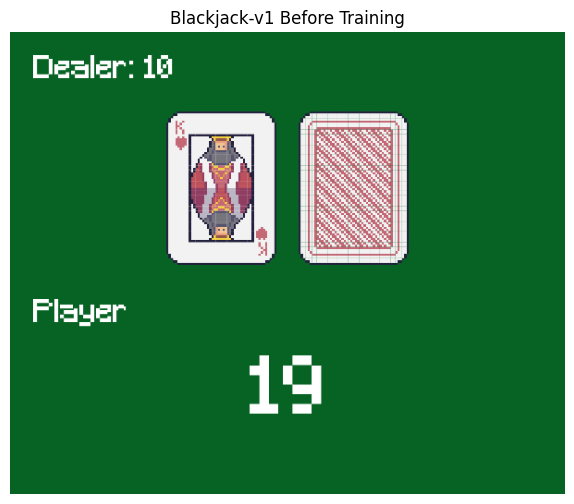

In [3]:
ENV_ID = "Blackjack-v1"
ACTION_NAMES = ["Stick", "Hit"]

env = gym.make(ENV_ID, natural=False, sab=False)
render_env = gym.make(ENV_ID, natural=False, sab=False, render_mode="rgb_array")

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = render_env.reset(seed=7)
print("Example state:", state)

frame = render_env.render()

plt.figure(figsize=(9, 6))
plt.imshow(frame)
plt.axis("off")
plt.title("Blackjack-v1 Before Training")
plt.show()

## 2. Q-Table Representation

The observation is a tuple rather than one integer, so the Q-table is stored as

$$
Q[p,d,u,a]
$$

where:

- $p$ = player sum;
- $d$ = dealer showing card;
- $u\in\{0,1\}$ = usable ace;
- $a\in\{0,1\}$ = action.

We allocate

$$
32\times11\times2\times2
$$

entries so the tuple can be used directly as an array index.

Only the state combinations that can actually occur during play are relevant.

## 3. Q-Learning Update

The standard Q-Learning update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

For Blackjack we use

$$
\gamma=1,
$$

because episodes are short and the final game result is the main reward.

## 4. Compute an Independent Reference $Q^*$

For this environment, we can calculate a reference optimal action-value function directly from the Blackjack rules.

The deck is treated as infinite, exactly as in Gymnasium's standard Blackjack environment. Card probabilities are:

$$
P(1)=P(2)=\cdots=P(9)=\frac{1}{13}
$$

and

$$
P(10)=\frac{4}{13}.
$$

For **Stick**, we compute the expected result against the dealer.

For **Hit**, we average over every possible next card and then use the best action from the resulting state.

Value iteration is repeated until the Q-values stop changing.

In [4]:
CARD_VALUES = np.arange(1, 11)
CARD_PROBS = np.array([1/13] * 9 + [4/13], dtype=float)

def add_card(total, usable_ace, card):
    total = int(total)
    usable_ace = bool(usable_ace)
    card = int(card)

    total += card

    if card == 1 and total + 10 <= 21:
        total += 10
        usable_ace = True

    if total > 21 and usable_ace:
        total -= 10
        usable_ace = False

    return total, usable_ace

def initial_two_card_state(card1, card2):
    total, usable = add_card(0, False, card1)
    total, usable = add_card(total, usable, card2)
    return total, usable

@lru_cache(None)
def dealer_terminal_distribution(total, usable_ace):
    total = int(total)
    usable_ace = bool(usable_ace)

    if total > 21:
        return {22: 1.0}

    if total >= 17:
        return {total: 1.0}

    distribution = {}

    for card, prob in zip(CARD_VALUES, CARD_PROBS):
        next_total, next_usable = add_card(total, usable_ace, int(card))
        sub = dealer_terminal_distribution(next_total, next_usable)

        for outcome, sub_prob in sub.items():
            distribution[outcome] = distribution.get(outcome, 0.0) + prob * sub_prob

    return distribution

@lru_cache(None)
def dealer_distribution_from_showing(dealer_showing):
    final_distribution = {}

    for hidden_card, prob in zip(CARD_VALUES, CARD_PROBS):
        total, usable = initial_two_card_state(int(dealer_showing), int(hidden_card))
        sub = dealer_terminal_distribution(total, usable)

        for outcome, sub_prob in sub.items():
            final_distribution[outcome] = final_distribution.get(outcome, 0.0) + prob * sub_prob

    return final_distribution

def stick_value(player_sum, dealer_showing):
    distribution = dealer_distribution_from_showing(int(dealer_showing))
    expected_reward = 0.0

    for dealer_outcome, prob in distribution.items():
        if dealer_outcome == 22:
            reward = 1.0
        elif player_sum > dealer_outcome:
            reward = 1.0
        elif player_sum < dealer_outcome:
            reward = -1.0
        else:
            reward = 0.0

        expected_reward += prob * reward

    return expected_reward

def compute_blackjack_q_star(gamma=1.0, tol=1e-12):
    Q = np.zeros((32, 11, 2, 2), dtype=float)

    for _ in range(10000):
        Q_new = Q.copy()

        for player_sum in range(4, 22):
            for dealer_showing in range(1, 11):
                for usable_ace in [0, 1]:

                    # Action 0: Stick
                    Q_new[player_sum, dealer_showing, usable_ace, 0] = stick_value(
                        player_sum,
                        dealer_showing
                    )

                    # Action 1: Hit
                    hit_value = 0.0

                    for card, prob in zip(CARD_VALUES, CARD_PROBS):
                        next_sum, next_usable = add_card(
                            player_sum,
                            bool(usable_ace),
                            int(card)
                        )

                        if next_sum > 21:
                            continuation = -1.0
                        else:
                            continuation = gamma * np.max(
                                Q[next_sum, dealer_showing, int(next_usable)]
                            )

                        hit_value += prob * continuation

                    Q_new[player_sum, dealer_showing, usable_ace, 1] = hit_value

        delta = np.max(np.abs(Q_new - Q))
        Q = Q_new

        if delta < tol:
            break

    return Q

Q_star = compute_blackjack_q_star()

print("Reference Q* computed.")

Reference Q* computed.


In [5]:
reference_rows = []

for player_sum in range(4, 22):
    for dealer_showing in range(1, 11):
        for usable_ace in [0, 1]:
            reference_rows.append({
                "Player Sum": player_sum,
                "Dealer Showing": dealer_showing,
                "Usable Ace": bool(usable_ace),
                "Q*(Stick)": Q_star[player_sum, dealer_showing, usable_ace, 0],
                "Q*(Hit)": Q_star[player_sum, dealer_showing, usable_ace, 1],
                "Optimal Action": ACTION_NAMES[
                    np.argmax(Q_star[player_sum, dealer_showing, usable_ace])
                ]
            })

q_star_df = pd.DataFrame(reference_rows)

print("Reference optimal Q-table:")
display(q_star_df.round(4))

Reference optimal Q-table:


,Player Sum,Dealer Showing,Usable Ace,Q*(Stick),Q*(Hit),Optimal Action
0,4,1,False,-0.7694,-0.4478,Hit
1,4,1,True,-0.7694,-0.2568,Hit
2,4,2,False,-0.2928,-0.1149,Hit
3,4,2,True,-0.2928,0.1092,Hit
4,4,3,False,-0.2523,-0.0826,Hit
5,4,3,True,-0.2523,0.1346,Hit
6,4,4,False,-0.2111,-0.0494,Hit
7,4,4,True,-0.2111,0.1609,Hit
8,4,5,False,-0.1672,-0.0124,Hit
9,4,5,True,-0.1672,0.1893,Hit


## 5. Train the Q-Learning Agent

Training uses:

$$
\alpha=0.02,\qquad \gamma=1.
$$

The agent follows an $\epsilon$-greedy behavior policy.

Because Blackjack contains stochastic card draws, many episodes are needed for stable estimates.

We record:

- return;
- episode length;
- exploration rate;
- the first 60 individual Q-value updates;
- RMSE between the learned values and the independently computed reference $Q^*$ over visited states.

In [6]:
def train_q_learning(
    n_episodes=500000,
    alpha=0.02,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99998,
    seed=7
):
    rng = np.random.default_rng(seed)

    Q = np.zeros((32, 11, 2, 2), dtype=float)
    visit_counts = np.zeros((32, 11, 2), dtype=int)

    history = []
    update_log = []

    epsilon = epsilon_start
    update_number = 0

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        step = 0

        while True:
            step += 1

            p, d, u = int(state[0]), int(state[1]), int(state[2])
            visit_counts[p, d, u] += 1

            if rng.random() < epsilon:
                action = int(rng.integers(2))
                selection = "explore"
            else:
                q_values = Q[p, d, u]
                best_actions = np.flatnonzero(np.isclose(q_values, q_values.max()))
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_state, reward, terminated, truncated, _ = env.step(action)

            old_q = Q[p, d, u, action]

            if terminated or truncated:
                max_next_q = 0.0
                target = reward
            else:
                np_sum, nd, nu = int(next_state[0]), int(next_state[1]), int(next_state[2])
                max_next_q = np.max(Q[np_sum, nd, nu])
                target = reward + gamma * max_next_q

            td_error = target - old_q
            Q[p, d, u, action] += alpha * td_error

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "State": state,
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next State": next_state,
                    "Max Next Q": max_next_q,
                    "Old Q": old_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": Q[p, d, u, action],
                    "Epsilon": epsilon
                })

            total_reward += reward

            if terminated or truncated:
                break

            state = next_state

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if episode % 1000 == 0:
            visited = visit_counts > 0
            learned_values = Q[visited]
            reference_values = Q_star[visited]
            rmse = np.sqrt(np.mean((learned_values - reference_values) ** 2))

            history.append({
                "Episode": episode,
                "Mean Return, Last Block": np.nan,
                "Epsilon": epsilon,
                "Visited States": int(visited.sum()),
                "Q RMSE on Visited States": rmse
            })

    return Q, visit_counts, pd.DataFrame(history), pd.DataFrame(update_log)

Q, visit_counts, history, update_log = train_q_learning()

print("Training complete.")
print("Visited states:", int((visit_counts > 0).sum()))
display(history.tail())

Training complete.
Visited states: 280


,Episode,"Mean Return, Last Block",Epsilon,Visited States,Q RMSE on Visited States
495,496000,NaN,0.05,280,0.105079
496,497000,NaN,0.05,280,0.104780
497,498000,NaN,0.05,280,0.104487
498,499000,NaN,0.05,280,0.105105
499,500000,NaN,0.05,280,0.105105


## 6. First 60 Q-Value Updates

In [7]:
display(update_log.round(4))

,Update,Episode,Step,State,Action,Reward,Next State,Max Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,"(14, 10, 0)",Hit,-1.0,"(23, 10, 0)",0.0,0.00,-1.0,-1.00,-0.0200,1.0000
1,2,2,1,"(14, 6, 0)",Hit,-1.0,"(22, 6, 0)",0.0,0.00,-1.0,-1.00,-0.0200,1.0000
2,3,3,1,"(7, 10, 0)",Stick,-1.0,"(7, 10, 0)",0.0,0.00,-1.0,-1.00,-0.0200,1.0000
3,4,4,1,"(17, 2, 0)",Stick,1.0,"(17, 2, 0)",0.0,0.00,1.0,1.00,0.0200,0.9999
4,5,5,1,"(20, 8, 0)",Stick,1.0,"(20, 8, 0)",0.0,0.00,1.0,1.00,0.0200,0.9999
5,6,6,1,"(20, 10, 0)",Hit,-1.0,"(30, 10, 0)",0.0,0.00,-1.0,-1.00,-0.0200,0.9999
6,7,7,1,"(14, 2, 0)",Hit,-1.0,"(24, 2, 0)",0.0,0.00,-1.0,-1.00,-0.0200,0.9999
7,8,8,1,"(20, 10, 0)",Stick,0.0,"(20, 10, 0)",0.0,0.00,0.0,0.00,0.0000,0.9999
8,9,9,1,"(16, 8, 0)",Hit,0.0,"(18, 8, 0)",0.0,0.00,0.0,0.00,0.0000,0.9998
9,10,9,2,"(18, 8, 0)",Stick,1.0,"(18, 8, 0)",0.0,0.00,1.0,1.00,0.0200,0.9998


## 7. Convergence Graph

The convergence measure is the RMSE between the learned Q-values and the independently computed reference $Q^*$ over states that have been visited during training.

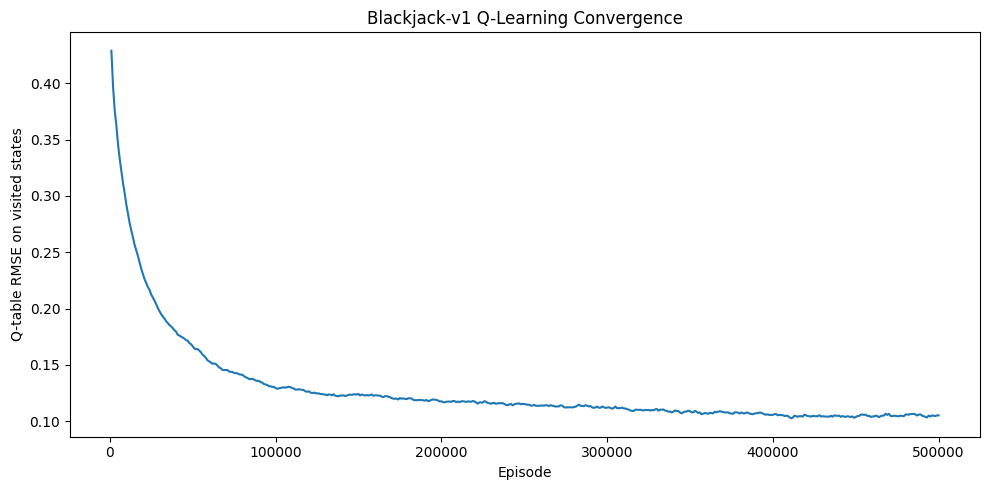

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history["Episode"], history["Q RMSE on Visited States"])
plt.xlabel("Episode")
plt.ylabel("Q-table RMSE on visited states")
plt.title("Blackjack-v1 Q-Learning Convergence")
plt.tight_layout()
plt.show()

## 8. Learned Q-Table

The complete learned table is converted into a readable DataFrame.

Each row corresponds to one state:

$$
(\text{player sum},\text{dealer showing},\text{usable ace}).
$$

In [9]:
learned_rows = []

for player_sum in range(4, 22):
    for dealer_showing in range(1, 11):
        for usable_ace in [0, 1]:
            learned_rows.append({
                "Player Sum": player_sum,
                "Dealer Showing": dealer_showing,
                "Usable Ace": bool(usable_ace),
                "Q(Stick)": Q[player_sum, dealer_showing, usable_ace, 0],
                "Q(Hit)": Q[player_sum, dealer_showing, usable_ace, 1],
                "Greedy Action": ACTION_NAMES[
                    np.argmax(Q[player_sum, dealer_showing, usable_ace])
                ],
                "Visits": visit_counts[player_sum, dealer_showing, usable_ace]
            })

learned_q_df = pd.DataFrame(learned_rows)
display(learned_q_df.round(4))

,Player Sum,Dealer Showing,Usable Ace,Q(Stick),Q(Hit),Greedy Action,Visits
0,4,1,False,-0.4392,-0.4158,Hit,209
1,4,1,True,0.0000,0.0000,Stick,0
2,4,2,False,-0.1978,-0.1364,Hit,230
3,4,2,True,0.0000,0.0000,Stick,0
4,4,3,False,-0.1479,-0.1009,Hit,217
5,4,3,True,0.0000,0.0000,Stick,0
6,4,4,False,-0.0360,-0.0186,Hit,231
7,4,4,True,0.0000,0.0000,Stick,0
8,4,5,False,-0.0819,-0.0472,Hit,231
9,4,5,True,0.0000,0.0000,Stick,0


## 9. Learned Q vs. Reference $Q^*$

The next table makes it easy to inspect how close the learned values are to the independently computed optimal values.

In [10]:
comparison = learned_q_df.merge(
    q_star_df,
    on=["Player Sum", "Dealer Showing", "Usable Ace"]
)

display(comparison.round(4))

,Player Sum,Dealer Showing,Usable Ace,Q(Stick),Q(Hit),Greedy Action,Visits,Q*(Stick),Q*(Hit),Optimal Action
0,4,1,False,-0.4392,-0.4158,Hit,209,-0.7694,-0.4478,Hit
1,4,1,True,0.0000,0.0000,Stick,0,-0.7694,-0.2568,Hit
2,4,2,False,-0.1978,-0.1364,Hit,230,-0.2928,-0.1149,Hit
3,4,2,True,0.0000,0.0000,Stick,0,-0.2928,0.1092,Hit
4,4,3,False,-0.1479,-0.1009,Hit,217,-0.2523,-0.0826,Hit
5,4,3,True,0.0000,0.0000,Stick,0,-0.2523,0.1346,Hit
6,4,4,False,-0.0360,-0.0186,Hit,231,-0.2111,-0.0494,Hit
7,4,4,True,0.0000,0.0000,Stick,0,-0.2111,0.1609,Hit
8,4,5,False,-0.0819,-0.0472,Hit,231,-0.1672,-0.0124,Hit
9,4,5,True,0.0000,0.0000,Stick,0,-0.1672,0.1893,Hit


## 10. Visualize the Learned Policy

A Blackjack policy is easier to understand as a map than as hundreds of Q-values.

We therefore show two policy heatmaps:

1. no usable ace;
2. usable ace.

The cell value is:

- $0=$ Stick
- $1=$ Hit.

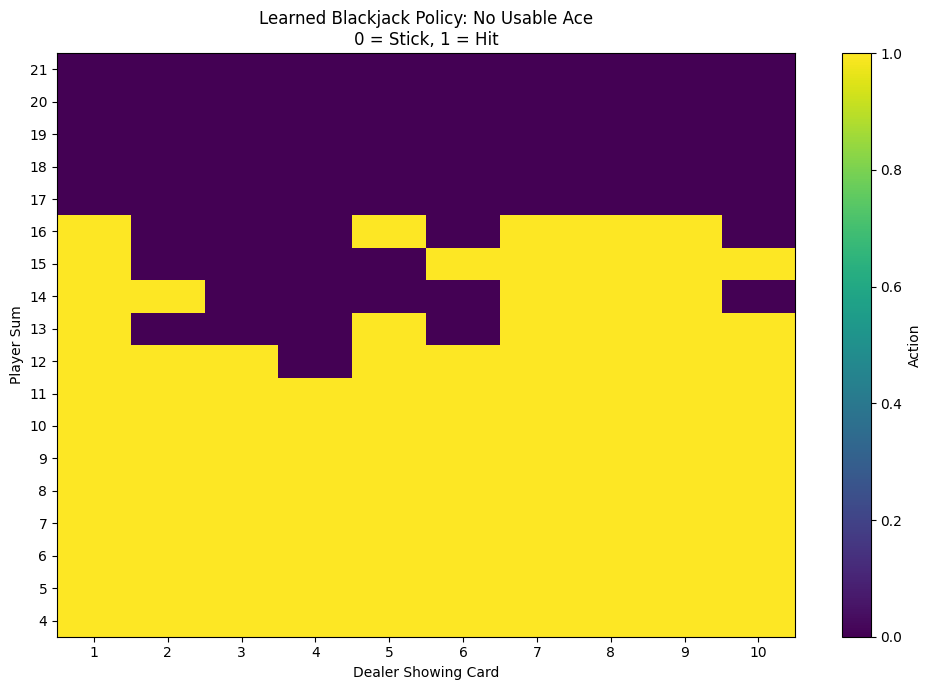

In [11]:
def policy_matrix(Q, usable_ace):
    matrix = np.zeros((18, 10), dtype=int)

    for i, player_sum in enumerate(range(4, 22)):
        for j, dealer_showing in enumerate(range(1, 11)):
            matrix[i, j] = int(
                np.argmax(Q[player_sum, dealer_showing, usable_ace])
            )

    return matrix

policy_no_ace = policy_matrix(Q, 0)
policy_usable_ace = policy_matrix(Q, 1)

plt.figure(figsize=(10, 7))
plt.imshow(policy_no_ace, aspect="auto", origin="lower")
plt.xticks(range(10), range(1, 11))
plt.yticks(range(18), range(4, 22))
plt.xlabel("Dealer Showing Card")
plt.ylabel("Player Sum")
plt.title("Learned Blackjack Policy: No Usable Ace\n0 = Stick, 1 = Hit")
plt.colorbar(label="Action")
plt.tight_layout()
plt.show()

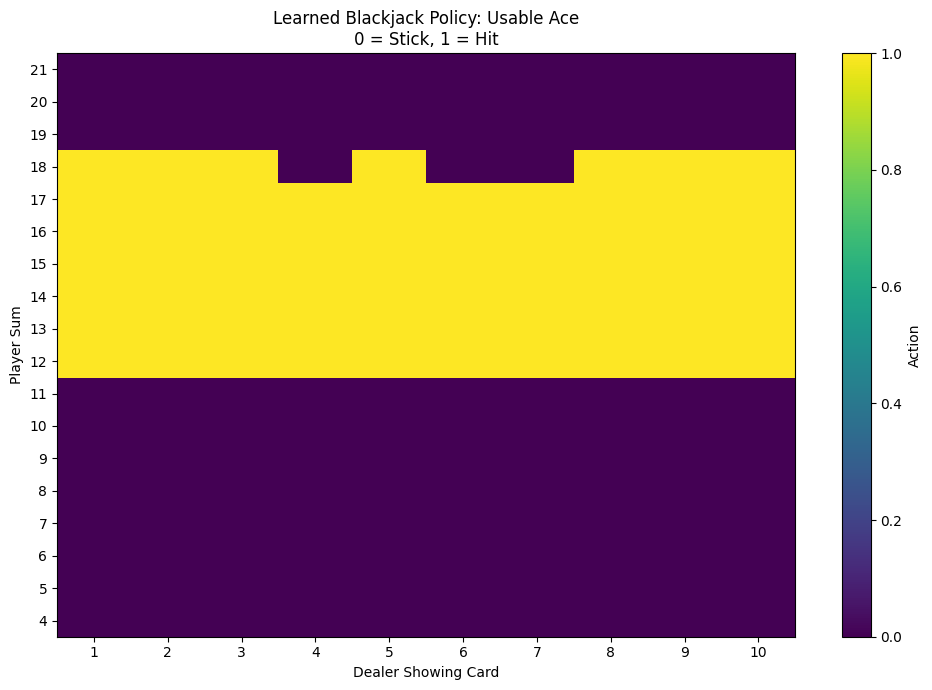

In [12]:
plt.figure(figsize=(10, 7))
plt.imshow(policy_usable_ace, aspect="auto", origin="lower")
plt.xticks(range(10), range(1, 11))
plt.yticks(range(18), range(4, 22))
plt.xlabel("Dealer Showing Card")
plt.ylabel("Player Sum")
plt.title("Learned Blackjack Policy: Usable Ace\n0 = Stick, 1 = Hit")
plt.colorbar(label="Action")
plt.tight_layout()
plt.show()

## 11. Evaluate the Trained Agent

We compare the trained greedy policy over many independent games.

In [13]:
def evaluate_agent(Q, n_episodes=100000, seed=100000):
    wins = 0
    draws = 0
    losses = 0
    returns = []

    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode)

        while True:
            p, d, u = int(state[0]), int(state[1]), int(state[2])
            action = int(np.argmax(Q[p, d, u]))

            state, reward, terminated, truncated, _ = env.step(action)

            if terminated or truncated:
                returns.append(reward)

                if reward > 0:
                    wins += 1
                elif reward == 0:
                    draws += 1
                else:
                    losses += 1

                break

    return pd.DataFrame([{
        "Episodes": n_episodes,
        "Win Rate": wins / n_episodes,
        "Draw Rate": draws / n_episodes,
        "Loss Rate": losses / n_episodes,
        "Mean Return": np.mean(returns)
    }])

evaluation = evaluate_agent(Q)
display(evaluation.round(4))

,Episodes,Win Rate,Draw Rate,Loss Rate,Mean Return
0,100000,0.4262,0.0935,0.4803,-0.0541


## 12. Run the Trained Agent in the Rendered Environment

The following cell plays one full episode with the greedy learned policy and stores the actual Gymnasium rendered frames as a GIF for Colab.

Decisions:
State (20, 10, 1) -> Stick
Final reward: 0.0


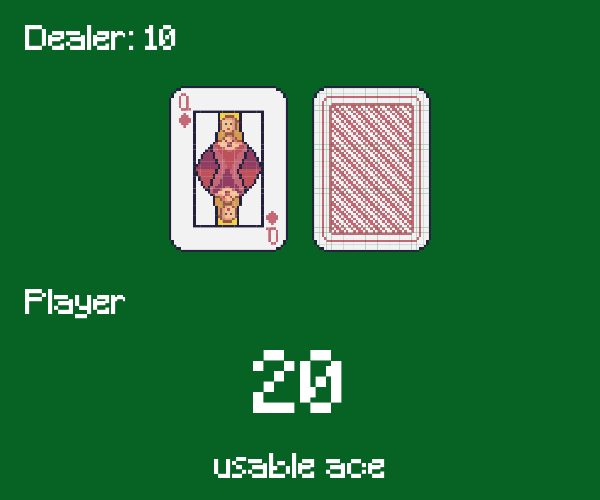

In [14]:
def save_gif(frames, filename, duration=0.8):
    imageio.mimsave(filename, frames, duration=duration, loop=0)
    display(IPyImage(filename=filename))

def record_trained_agent(Q, filename="blackjack_trained_agent.gif", seed=2026):
    frames = []
    actions = []

    state, _ = render_env.reset(seed=seed)
    frames.append(render_env.render())

    while True:
        p, d, u = int(state[0]), int(state[1]), int(state[2])
        action = int(np.argmax(Q[p, d, u]))
        actions.append((state, ACTION_NAMES[action]))

        state, reward, terminated, truncated, _ = render_env.step(action)
        frames.append(render_env.render())

        if terminated or truncated:
            break

    print("Decisions:")
    for s, a in actions:
        print(f"State {s} -> {a}")

    print("Final reward:", reward)

    save_gif(frames, filename, duration=0.9)

record_trained_agent(Q)

## 13. Portfolio Takeaway

Blackjack demonstrates how Q-Learning can learn a decision rule in a stochastic environment.

The key progression is:

$$
(\text{player sum},\text{dealer card},\text{usable ace})
\rightarrow
Q(s,\text{Stick}),Q(s,\text{Hit})
\rightarrow
\text{learned decision policy}.
$$

The policy heatmaps are especially useful because they convert a large Q-table into an interpretable decision rule.